In [3]:
# ==================== СЕКЦІЯ 1: ЗАВАНТАЖЕННЯ БІБЛІОТЕК ====================
# Ця клітинка завантажує всі необхідні бібліотеки для аналізу даних та машинного навчання

# Бібліотеки для обробки та аналізу даних
import pandas as pd      # Для роботи з таблицями даних (DataFrame)
import numpy as np       # Для математичних операцій та роботи з масивами

# Бібліотеки для візуалізації
import matplotlib.pyplot as plt  # Для створення графіків та діаграм
import seaborn as sns            # Розширена функціональність для красивих графіків

# Бібліотеки машинного навчання (scikit-learn)
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split  # Розділення даних на тренування та тестування
from sklearn.preprocessing import StandardScaler, OneHotEncoder  # Нормалізація та кодування даних
from sklearn.impute import SimpleImputer  # Заповнення пропущених значень
from sklearn.compose import ColumnTransformer  # Трансформування різних типів колонок
from sklearn.pipeline import Pipeline  # Створення конвеєра обробки даних

# Класифікатори (моделі машинного навчання)
from sklearn.linear_model import LogisticRegression  # Логістична регресія
from sklearn.ensemble import RandomForestClassifier  # Випадковий ліс
from sklearn.svm import SVC  # Метод опорних векторів (SVM)

# Метрики оцінки якості моделей
from sklearn.metrics import (
    accuracy_score,           # Точність - відсоток правильних передбачень
    precision_score,          # Точність позитивного класу
    recall_score,             # Повнота - здатність знайти всі позитивні випадки
    f1_score,                 # Гармонійне середнє точності та повноти
    roc_auc_score,            # Площа під ROC-кривою
    confusion_matrix,         # Матриця помилок класифікації
    classification_report,    # Детальний звіт про класифікацію
    roc_curve,                # ROC-крива для аналізу моделі
    ConfusionMatrixDisplay    # Клас для візуалізації матриці помилок
)

import joblib  # Для збереження та завантаження навчених моделей

# Налаштування стилю графіків для кращої презентації
sns.set(style="whitegrid")  # Сітка на фоні графіків
plt.rcParams['figure.figsize'] = (10, 6)  # Розмір графіків за замовчуванням

print("Бібліотеки успішно завантажені.")

Бібліотеки успішно завантажені.


In [4]:
# ==================== СЕКЦІЯ 2: ЗАВАНТАЖЕННЯ ТА РОЗВІДКА ДАНИХ ====================
# Ця клітинка завантажує набір даних про серцево-судинні захворювання та проводить первинний аналіз

# Завантаження CSV-файлу в DataFrame (таблицю даних)
df = pd.read_csv('heart_disease.csv')

# Виведення перших 5 рядків для розуміння структури даних
print("Перші 5 рядків датасету:")
display(df.head())

# Виведення інформації про типи даних та наявність пропущених значень
# info() показує:
#   - назву кожної колонки
#   - кількість непустих значень
#   - тип даних (int, float, object тощо)
#   - використання пам'яті
print("\nІнформація про датасет:")
print(df.info())

# Перевірка на наявність дублікатів (однакові рядки в датасеті)
# duplicated() повертає булеве значення для кожного рядка
# sum() рахує True значення (дублікати)
print(f"\nКількість дублікатів: {df.duplicated().sum()}")

Перші 5 рядків датасету:


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0



Інформація про датасет:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB
None

Кількість дублікатів: 0


In [5]:
# ==================== СЕКЦІЯ 3: ОЧИЩЕННЯ ТА ОБРОБКА ДАНИХ ====================
# Ця клітинка виконує кроки попередньої обробки даних для підготовки до машинного навчання

# --- Крок 1: Видалення непотрібних колонок ---
# 'id' та 'dataset' - метаекономічні дані, які не впливають на діагноз
# Ці колонки не мають прогностичної цінності і можуть внести шум у модель
df_clean = df.drop(['id', 'dataset'], axis=1)

# --- Крок 2: Перетворення цільової змінної 'num' в бінарну класифікацію ---
# Оригінальні значення: 0 = здоровий, 1-4 = різні ступені хвороби
# Нам потрібна бінарна класифікація (0 або 1) для простішого навчання моделі
# lambda x: 1 if x > 0 else 0  →  якщо значення > 0, то 1 (хворий), інакше 0 (здоровий)
df_clean['target'] = df_clean['num'].apply(lambda x: 1 if x > 0 else 0)
df_clean = df_clean.drop('num', axis=1)  # Видалення оригінальної колонки

print("\nРозподіл цільової змінної (target):")
print(df_clean['target'].value_counts())  # Показує скільки здорових (0) та хворих (1)

# --- Крок 3: Кодування категоріальних ознак ---
# 'sex': Male → 1, Female → 0 (числовое кодування для моделей)
df_clean['sex'] = df_clean['sex'].map({'Male': 1, 'Female': 0})

# 'fbs' (високий рівень цукру) та 'exang' (стенокардія при навантаженні)
# Можуть мати різні формати (True/False, 1/0, рядки)
# Приводимо до стандартного формату 0/1
for col in ['fbs', 'exang']:
    df_clean[col] = df_clean[col].astype(str).map({
        'True': 1, 'False': 0,  # Булеві значення
        '1': 1, '0': 0          # Рядкові представлення чисел
    })

# --- Крок 4: Обробка пропущених значень (Imputation) ---
# Розділяємо колонки на числові та категоріальні для різної обробки

# Числові ознаки (медичні показники з числовими значеннями)
numeric_features = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']

# Категоріальні ознаки (різні типи класифікацій та показників)
categorical_features = ['cp', 'restecg', 'slope', 'thal']

# Імп'ютер для числових даних - заповнює пропуски медіаною
# Медіана стійка до екстремальних значень (викидів)
imputer_num = SimpleImputer(strategy='median')

# Імп'ютер для категоріальних даних - заповнює пропуски модою (найчастішим значенням)
imputer_cat = SimpleImputer(strategy='most_frequent')

# Застосування імп'ютерів до відповідних колонок
df_clean[numeric_features] = imputer_num.fit_transform(df_clean[numeric_features])
df_clean[categorical_features] = imputer_cat.fit_transform(df_clean[categorical_features])

# Заповнення залишкових пропусків у бінарних колонках модою
# (якщо після попередніх кроків залишилися пропуски)
for col in ['sex', 'fbs', 'exang']:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

# Перевірка: виводимо кількість пропусків в кожній колонці
# Ідеально - всі значення повинні бути 0
print("\nПеревірка на пропуски після очищення:")
print(df_clean.isnull().sum())


Розподіл цільової змінної (target):
target
1    509
0    411
Name: count, dtype: int64

Перевірка на пропуски після очищення:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


C:\Users\blads\AppData\Local\Temp\ipykernel_1768\3567610428.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df_clean, palette='viridis')  # Стовпчаста діаграма


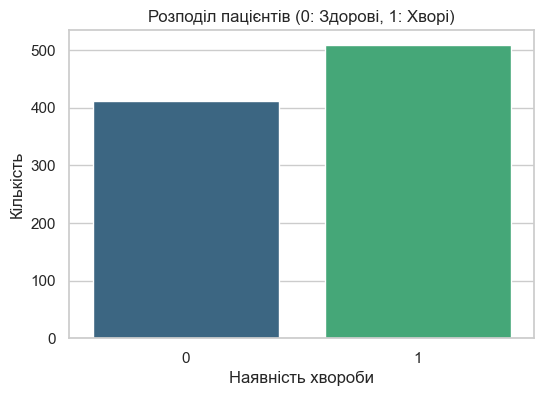

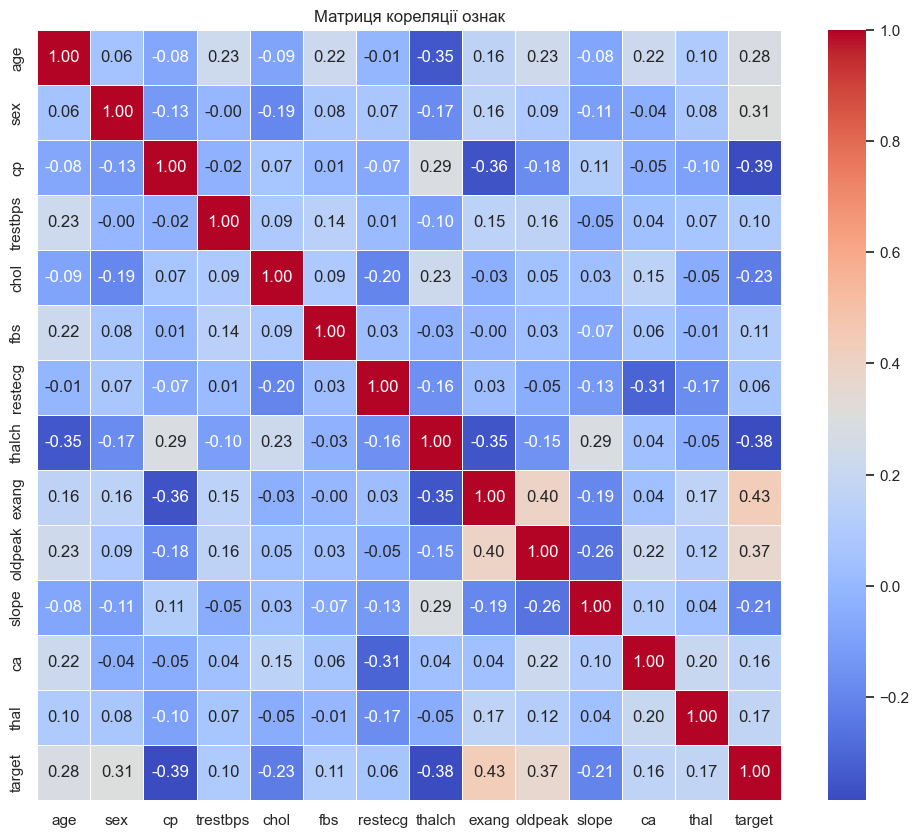

In [6]:
# ==================== СЕКЦІЯ 4: ДОСЛІДНИЦЬКА ВІЗУАЛІЗАЦІЯ ДАНИХ (EDA) ====================
# Ця клітинка створює графіки для розуміння розподілу та залежностей у даних

# --- Графік 1: Розподіл цільової змінної ---
# Показує, скільки пацієнтів здорових (0) та хворих (1)
# Дисбаланс класів може вплинути на навчання моделі
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df_clean, palette='viridis')  # Стовпчаста діаграма
plt.title('Розподіл пацієнтів (0: Здорові, 1: Хворі)')
plt.xlabel('Наявність хвороби')
plt.ylabel('Кількість')
plt.show()

# --- Графік 2: Матриця кореляції ---
# Показує, як різні ознаки залежать одна від одної
# Кореляція від -1 до 1:
#   1 = позитивна залежність (обидві зростають разом)
#  -1 = негативна залежність (одна зростає, друга спадає)
#   0 = немає залежності

# Копіюємо дані для тимчасової трансформації
df_corr = df_clean.copy()

# Кореляція потребує числових значень, тому категоріальні дані перетворюємо на коди
for col in categorical_features:
    # astype('category') - перетворює на категорійний тип
    # cat.codes - призначає числові коди кожній категорії
    df_corr[col] = df_corr[col].astype('category').cat.codes

plt.figure(figsize=(12, 10))
# Розраховуємо матрицю кореляції між усіма числовими ознаками
corr_matrix = df_corr.corr()

# Креслимо теплову карту
# annot=True - показує числові значення кореляції
# fmt=".2f" - формат з 2 знаками після коми
# cmap='coolwarm' - колірна схема (холодні кольори = низька кореляція)
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Матриця кореляції ознак')
plt.show()

In [7]:
# ==================== СЕКЦІЯ 5: ПІДГОТОВКА ДАНИХ ДЛЯ НАВЧАННЯ МОДЕЛЕЙ ====================
# Ця клітинка виконує фінальну обробку та розділення даних

# --- Крок 1: One-Hot Encoding категоріальних змінних ---
# One-Hot Encoding перетворює категоріальні ознаки у формат, який розуміють моделі
# Приклад: якщо 'cp' має значення [A, B, C], то створюються колонки:
#   cp_A: 1 якщо cp=A, 0 інакше
#   cp_B: 1 якщо cp=B, 0 інакше
#   cp_C: 1 якщо cp=C, 0 інакше
# drop_first=True - видаляє першу колонку, щоб уникнути мультиколінеарності
df_final = pd.get_dummies(df_clean, columns=categorical_features, drop_first=True)

# --- Крок 2: Розділення на ознаки (X) та цільову змінну (y) ---
# X - матриця ознак (все крім цільової змінної)
# y - вектор цільової змінної (те, що ми передбачаємо)
X = df_final.drop('target', axis=1)
y = df_final['target']

# --- Крок 3: Train-Test Split ---
# Розділяємо дані на тренувальну (80%) та тестову (20%) вибірки
# random_state=42 - фіксує випадковість для відтворюваності результатів
# stratify=y - зберігає пропорції класів у обох вибірках
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # 20% для тестування
    random_state=42, 
    stratify=y          # Зберігає розподіл класів
)

# --- Крок 4: Нормалізація даних (StandardScaler) ---
# Масштабування приводить всі ознаки до однієї шкали (середнє=0, дисперсія=1)
# Це важливо для:
#   - SVM (чутлива до масштабування)
#   - Логістичної регресії (швидше сходиться)
# Крім того, забезпечує більшу інформативність ознак у моделі

scaler = StandardScaler()

# fit_transform на тренувальних даних: обчислює параметри масштабування та застосовує їх
X_train_scaled = scaler.fit_transform(X_train)

# transform на тестових даних: застосовує ті самі параметри (без переобчислення)
# Це запобігає витоку інформації з тестової вибірки
X_test_scaled = scaler.transform(X_test)

# Виведення розмірів вибірок
print(f"Розмір тренувальної вибірки: {X_train_scaled.shape}")  # (кількість прикладів, кількість ознак)
print(f"Розмір тестової вибірки: {X_test_scaled.shape}")

Розмір тренувальної вибірки: (736, 18)
Розмір тестової вибірки: (184, 18)


In [8]:

# ==================== СЕКЦІЯ 6.1: КРОС-ВАЛІДАЦІЯ МОДЕЛЕЙ ====================
# Ця клітинка виконує крос-валідацію (перехресну перевірку) для оцінки стабільності моделей

# --- Крок 1: Визначення словника моделей ---
# Створюємо словник з назвами моделей як ключами та об'єктами моделей як значеннями
# Це дозволяє легко ітерувати по всім моделям в циклі
models = {
    # Логістична регресія - простий лінійний класифікатор
    # random_state=42 - фіксує випадковість для відтворюваності
    "Logistic Regression": LogisticRegression(random_state=42),
    
    # Random Forest - ансамбль дерев рішень
    # n_estimators=100 - 100 дерев в ансамблі (чим більше - то більш стійко, але повільніше)
    # max_depth=10 - максимальна глибина кожного дерева (запобігає переобученню)
    # random_state=42 - для відтворюваності
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42),
    
    # SVM - метод опорних векторів
    # kernel='rbf' - радіальне базисне функціональне ядро (для нелінійної класифікації)
    # C=1.0 - параметр регуляризації (чим менше - то більш гладка границя)
    # probability=True - дозволяє отримувати ймовірності (необхідне для ROC-кривої)
    # random_state=42 - для відтворюваності
    "SVM": SVC(kernel='rbf', C=1.0, probability=True, random_state=42)
}

# --- Крок 2: Визначення стратегії крос-валідації ---
# StratifiedKFold дозволяє розділити дані на K частин (фолди) з зберіганням пропорцій класів
# Це особливо важливо для незбалансованих датасетів, де класів різна кількість
cv_strategy = StratifiedKFold(
    n_splits=5,        # Розділити дані на 5 фолдів (5-fold cross-validation)
    shuffle=True,      # Перемішати дані перед розділенням (для більшої статистичної значимості)
    random_state=42    # Фіксувати перемішування для відтворюваності
)

# --- Крок 3: Виконання крос-валідації для кожної моделі ---
print("--- Результати Крос-валідації (на X_train) ---")

# Ітеруємо по кожній моделі зі словника
for name, model in models.items():
    # cross_val_score() виконує крос-валідацію:
    # 1. Розділяє дані на 5 фолдів
    # 2. На кожному фолді:
    #    - Навчає модель на 4 фолдах (тренувальна вибірка)
    #    - Тестує на 1 фолді (тестова вибірка)
    # 3. Повертає масив оцінок (по одній для кожного фолду)
    # scoring='recall' - використовуємо Recall як метрику якості (найважливіше для медичного діагнозу)
    cv_scores = cross_val_score(
        model, 
        X_train_scaled,  # Матриця ознак (вже масштабована)
        y_train,         # Вектор цільової змінної
        cv=cv_strategy,  # Стратегія крос-валідації (StratifiedKFold)
        scoring='recall' # Метрика для оцінки (повнота/чутливість)
    )
    
    # Виведення результатів крос-валідації для кожної моделі
    print(f"\nМодель: {name}")
    
    # Показуємо оцінку на кожному фолді
    # Наприклад: [0.92, 0.88, 0.95, 0.90, 0.91] - це Recall для кожного з 5 фолдів
    print(f"   Recall на кожному фолді: {cv_scores}")
    
    # Розраховуємо середнє значення Recall по всім фолдам
    # mean() - середнє арифметичне оцінок
    # std() - стандартне відхилення (показує варіативність оцінок)
    # Низьке стандартне відхилення означає, що модель стабільна
    print(f"   Середній Recall (CV): {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
    
    # Після оцінки навчаємо модель на всій тренувальній вибірці
    # Це необхідно, щоб мати модель, навчену на максимальній кількості даних
    # перед фінальним тестуванням на тестовій вибірці
    model.fit(X_train_scaled, y_train)

# --- Крок 4: Збереження навчених моделей у змінні ---
# Витягуємо навчені моделі зі словника для подальшого використання
# Це дозволяє звертатися до них по імені (lr_model, rf_model, svm_model)
log_model = models["Logistic Regression"]
rf_model = models["Random Forest"]
svm_model = models["SVM"]

# Інформаційне повідомлення про завершення крос-валідації
print("\n[INFO] Всі моделі успішно навчені на повному тренувальному наборі.")
# Пояснення: Крос-валідація дала нам впевненість, що моделі стабільні
# Тепер вони знову навчені на всій вибірці для максимальної точності

--- Результати Крос-валідації (на X_train) ---

Модель: Logistic Regression
   Recall на кожному фолді: [0.85365854 0.87804878 0.81481481 0.85185185 0.77777778]
   Середній Recall (CV): 0.8352 (+/- 0.0351)

Модель: Random Forest
   Recall на кожному фолді: [0.87804878 0.8902439  0.87654321 0.85185185 0.85185185]
   Середній Recall (CV): 0.8697 (+/- 0.0153)

Модель: SVM
   Recall на кожному фолді: [0.90243902 0.87804878 0.81481481 0.85185185 0.85185185]
   Середній Recall (CV): 0.8598 (+/- 0.0293)

[INFO] Всі моделі успішно навчені на повному тренувальному наборі.


Розпочинаємо навчання моделей...


==================== Logistic Regression ====================
Accuracy: 0.8424
Precision: 0.8411
Recall: 0.8824
F1-Score: 0.8612
AUC-ROC: 0.9032

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.79      0.82        82
           1       0.84      0.88      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.84      0.84       184
weighted avg       0.84      0.84      0.84       184



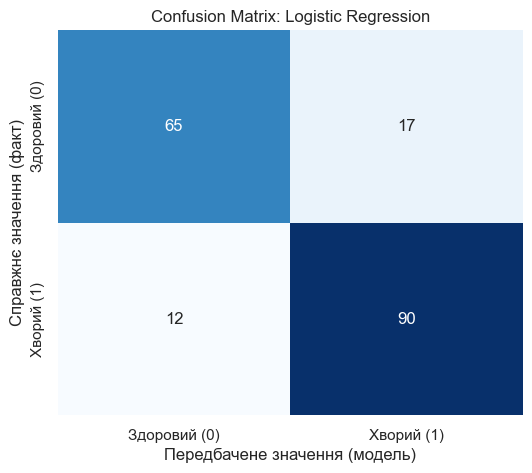

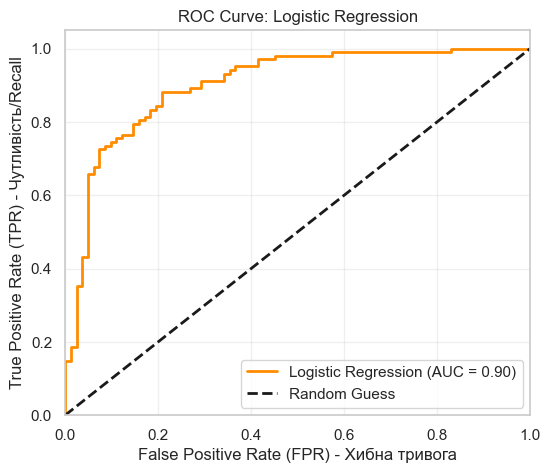

>>> КРИТИЧНО: Пропущених діагнозів (False Negatives): 12

==================== Random Forest ====================
Accuracy: 0.8424
Precision: 0.8288
Recall: 0.9020
F1-Score: 0.8638
AUC-ROC: 0.9083

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.77      0.81        82
           1       0.83      0.90      0.86       102

    accuracy                           0.84       184
   macro avg       0.85      0.84      0.84       184
weighted avg       0.84      0.84      0.84       184



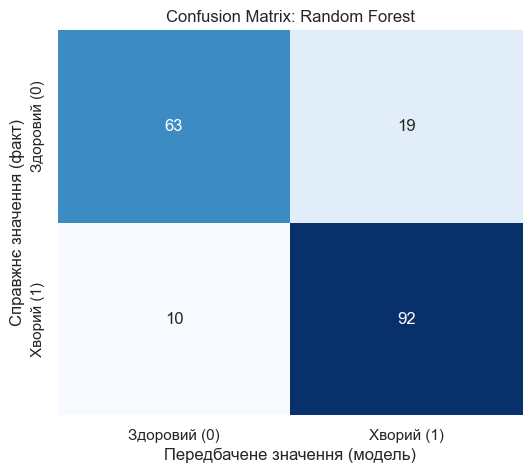

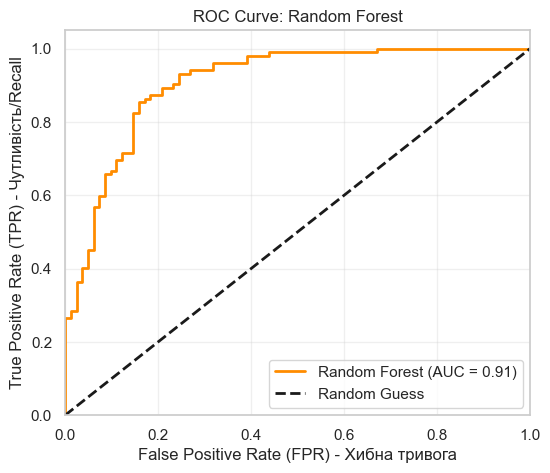

>>> КРИТИЧНО: Пропущених діагнозів (False Negatives): 10

==================== SVM ====================
Accuracy: 0.8533
Precision: 0.8319
Recall: 0.9216
F1-Score: 0.8744
AUC-ROC: 0.9192

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.77      0.82        82
           1       0.83      0.92      0.87       102

    accuracy                           0.85       184
   macro avg       0.86      0.84      0.85       184
weighted avg       0.86      0.85      0.85       184



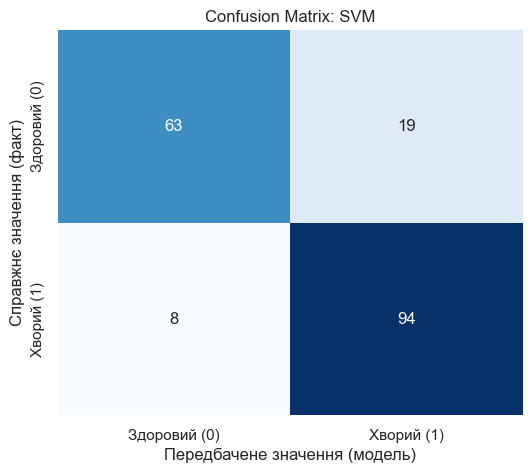

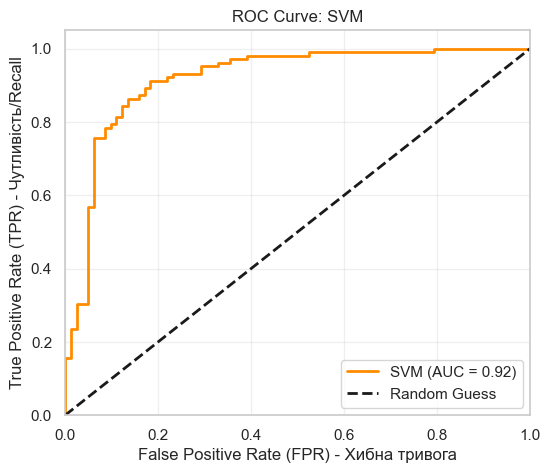

>>> КРИТИЧНО: Пропущених діагнозів (False Negatives): 8

Всі моделі успішно навчені та оцінені.


In [9]:
# ==================== СЕКЦІЯ 6.2: НАВЧАННЯ ТА ОЦІНКА МОДЕЛЕЙ ====================
# Ця клітинка визначає функцію для навчання та оцінки моделей з детальною статистикою

# Словник для збереження результатів оцінки всіх моделей
# Структура: {назва_моделі: {метрика: значення}}
# Наприклад: {"Logistic Regression": {"Accuracy": 0.85, "Precision": 0.88, ...}}
models_results = {}

def evaluate_model(model, name, X_train, y_train, X_test, y_test):
    """
    Функція навчає модель, робить прогнози та розраховує метрики якості.
    
    Параметри:
        model: об'єкт моделі scikit-learn для навчання
        name (str): назва моделі для виведення та збереження результатів
        X_train: матриця ознак тренувальної вибірки
        y_train: вектор цільової змінної тренувальної вибірки
        X_test: матриця ознак тестової вибірки
        y_test: вектор цільової змінної тестової вибірки
    
    Повертає:
        model: навчена модель
    """
    
    # --- Крок 1: Навчання моделі ---
    # fit() навчає модель на тренувальних даних
    # Це основний крок: модель вивчає закономірності в даних
    # Після цього крокує модель готова робити прогнози
    model.fit(X_train, y_train)
    
    # --- Крок 2: Прогнозування на тестовій вибірці ---
    # predict() робить класичні прогнози (0 або 1 для бінарної класифікації)
    # Це то, що моделька "думає" про кожен пацієнт
    y_pred = model.predict(X_test)
    
    # --- Крок 3: Отримання ймовірностей для детальної оцінки ---
    # Деяким метрикам (наприклад ROC-кривій) потрібні ймовірності, а не просто класи
    if hasattr(model, "predict_proba"):
        # predict_proba() повертає ймовірність для кожного класу
        # Повертає матрицю формату:
        #   [[ймовірність класу 0, ймовірність класу 1],
        #    [ймовірність класу 0, ймовірність класу 1],
        #    ...]
        # [:, 1] - беремо ймовірність класу 1 (хворий) для кожного прикладу
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        # SVM без параметра probability=True повертає decision_function
        # Це значення "впевненості" моделі (не ймовірність, але слідує тій же логіці)
        y_prob = model.decision_function(X_test)
    
    # --- Крок 4: Розрахунок метрик якості ---
    # Кожна метрика показує різні аспекти якості моделі
    
    # Accuracy (точність): відсоток правильних передбачень
    # Формула: (TP + TN) / (TP + TN + FP + FN)
    # АЛЕ: чутлива до дисбалансу класів! Якщо 90% хворих, модель може просто казати "всі хворі"
    acc = accuracy_score(y_test, y_pred)
    
    # Precision (точність позитивного класу): серед передбачених як "хворий", скільки справді хворих
    # Формула: TP / (TP + FP)
    # Важна метрика: низька точність = багато хибних тривог (здорових діагностовуємо як хворих)
    prec = precision_score(y_test, y_pred)
    
    # Recall (повнота/чутливість): серед усіх хворих, скільки моделька правильно визначила
    # Формула: TP / (TP + FN)
    # НАЙБІЛЬШ КРИТИЧНА для медичного діагнозу! Низький Recall = пропущені діагнози = небезпека!
    rec = recall_score(y_test, y_pred)
    
    # F1-Score: гармонійне середнє Precision та Recall
    # Формула: 2 * (Precision * Recall) / (Precision + Recall)
    # Балансує обидві метрики: якщо одна низька, то й F1 буде низький
    f1 = f1_score(y_test, y_pred)
    
    # AUC-ROC: площа під ROC-кривою (чим ближче до 1, тим краще)
    # Показує якість розділення класів незалежно від обраного порогу класифікації
    # Значення: 0.5 = випадкове вгадування, 1.0 = ідеальна модель
    roc_auc = roc_auc_score(y_test, y_prob)
    
    # --- Крок 5: Збереження результатів у глобальний словник ---
    # Це дозволяє порівнювати모делі після завершення навчання
    models_results[name] = {
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'AUC-ROC': roc_auc
    }
    
    # --- Крок 6: Виведення текстового звіту з результатами ---
    print(f"\n{'='*20} {name} {'='*20}")
    print(f"Accuracy: {acc:.4f}")     # .4f означає 4 знаки після коми
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"AUC-ROC: {roc_auc:.4f}")
    
    # Classification Report дає детальний звіт для кожного класу
    # Показує Precision, Recall, F1 для обох класів окремо
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    
    # --- Крок 7: Графік 1 - Матриця плутанини (Confusion Matrix) ---
    # Матриця 2x2 показує 4 типи результатів класифікації:
    # 
    #                   Передбачено
    #                  Здоровий  Хворий
    #  Справжнє  Здоровий   TN      FP    (справжні негативи vs хибні тривоги)
    #           Хворий     FN      TP    (пропущені діагнози vs вірні діагнози)
    #
    # Пояснення скорочень:
    # TP (True Positive): Правильно передбачено 1 - модель сказала "хворий" і це правда ✓
    # FP (False Positive): Помилково передбачено 1 - модель сказала "хворий" але це здоровий ✗
    # TN (True Negative): Правильно передбачено 0 - модель сказала "здоровий" і це правда ✓
    # FN (False Negative): Помилково передбачено 0 - модель сказала "здоровий" але це хворий ✗✗✗ НЕБЕЗПЕКА!
    
    plt.figure(figsize=(6, 5))
    # Розраховуємо матрицю плутанини
    cm = confusion_matrix(y_test, y_pred)  # Повертає [[TN, FP], [FN, TP]]
    
    # Креслимо тепловую карту для візуалізації
    # annot=True показує числові значення у клітинках
    # fmt='d' - формат цілих чисел
    # cmap='Blues' - синя колірна схема
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Здоровий (0)', 'Хворий (1)'], 
                yticklabels=['Здоровий (0)', 'Хворий (1)'])
    plt.title(f'Confusion Matrix: {name}')
    plt.ylabel('Справжнє значення (факт)')
    plt.xlabel('Передбачене значення (модель)')
    plt.show()
    
    # --- Крок 8: Графік 2 - ROC-крива ---
    # ROC (Receiver Operating Characteristic) крива показує компроміс між:
    # - True Positive Rate (TPR/Recall): скільки хворих знайдено (вісь Y)
    # - False Positive Rate (FPR): скільки здорових помилково діагностовано (вісь X)
    #
    # Крива наближається до верхнього лівого кута = краща модель (більше TPR, менше FPR)
    # Діагональна лінія (0,0) до (1,1) = випадкове вгадування (немає цінності)
    # Площа під кривою = AUC: 0.5 (гадаємо), 1.0 (ідеально)
    
    if hasattr(model, "predict_proba"):  # Робимо графік тільки для моделей з predict_proba
        plt.figure(figsize=(6, 5))
        # roc_curve() повертає False Positive Rate, True Positive Rate та пороги
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        
        # Креслимо ROC-криву
        plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})', 
                color='darkorange', lw=2)  # Основна крива моделі
        
        # Креслимо діагональ - лінія випадкового вгадування
        plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guess')
        
        # Налаштування осей та легенди
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate (FPR) - Хибна тривога')
        plt.ylabel('True Positive Rate (TPR) - Чутливість/Recall')
        plt.title(f'ROC Curve: {name}')
        plt.legend(loc="lower right")
        plt.grid(True, alpha=0.3)
        plt.show()

    # --- Крок 9: Аналіз критичних помилок ---
    # Витягуємо з матриці плутанини кількість False Negatives (FN)
    # FN = пропущені діагнози = модель сказала "здоровий", але насправді хворий
    # Це НАЙКРИТИЧНІШЕ для медичного діагнозу! Пропущений діагноз може стати смертельним
    fn = cm[1, 0]  # Індекс [1, 0] в матриці = FN
    
    # Виділяємо це увагою ">>>" та словом "КРИТИЧНО"
    print(f">>> КРИТИЧНО: Пропущених діагнозів (False Negatives): {fn}")
    # Ідеальне значення: 0 (жодних пропущених діагнозів)
    # Реальне значення > 0: вказує на проблеми з моделлю для медичного використання
    
    return model

print("Розпочинаємо навчання моделей...\n")

# --- Модель 1: Логістична Регресія ---
# Логістична регресія - простий, але потужний лінійний класифікатор
# Переваги: швидка, інтерпретовна (можна зрозуміти, як працює)
# Недоліки: часто недостатньо для складних закономірностей
# max_iter=1000 - максимальна кількість ітерацій оптимізації (знаходження найкращих параметрів)
lr_model = LogisticRegression(random_state=42, max_iter=1000)
# Викликаємо функцію для навчання, прогнозування та оцінки
_ = evaluate_model(lr_model, "Logistic Regression", X_train_scaled, y_train, X_test_scaled, y_test)

# --- Модель 2: Random Forest ---
# Random Forest - ансамбль (колекція) багатьох дерев рішень
# Кожне дерево вчиться на випадковій підмножині даних
# Потім прогнози усередняються = більш стійка модель
# Переваги: мобільна до шуму, часто точніша, менше переобучення
# Недоліки: повільніше, менш інтерпретовна
# n_estimators=100 - 100 дерев в ансамблі (100 дерев = добрий баланс точності та швидкості)
# max_depth=10 - максимальна глибина кожного дерева (запобігає переобученню/overfitting)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
_ = evaluate_model(rf_model, "Random Forest", X_train_scaled, y_train, X_test_scaled, y_test)

# --- Модель 3: SVM (Support Vector Machine) ---
# SVM - знаходить оптимальну границю (гіперплощину) між класами
# Правило: максимізує відстань між класами = найбільший margin
# kernel='rbf' - нелінійне Radial Basis Function ядро
#   RBF дозволяє моделювати складні (криволінійні) границі між класами
#   На відміну від лінійного ядра (kernel='linear')
# probability=True - дозволяє отримувати ймовірності за допомогою Platt scaling
#   Це необхідне для ROC-кривої та інших метрик, що потребують ймовірностей
# Переваги: потужна, добре працює з високорозмірними даними
# Недоліки: повільніша, чутлива до масштабування (тому потрібна нормалізація)
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
_ = evaluate_model(svm_model, "SVM", X_train_scaled, y_train, X_test_scaled, y_test)

print("\nВсі моделі успішно навчені та оцінені.")

Підсумкова таблиця метрик:


,Accuracy,Precision,Recall,F1-Score,AUC-ROC
SVM,0.853261,0.831858,0.921569,0.874419,0.919177
Random Forest,0.842391,0.828829,0.901961,0.863850,0.908297
Logistic Regression,0.842391,0.841121,0.882353,0.861244,0.903156


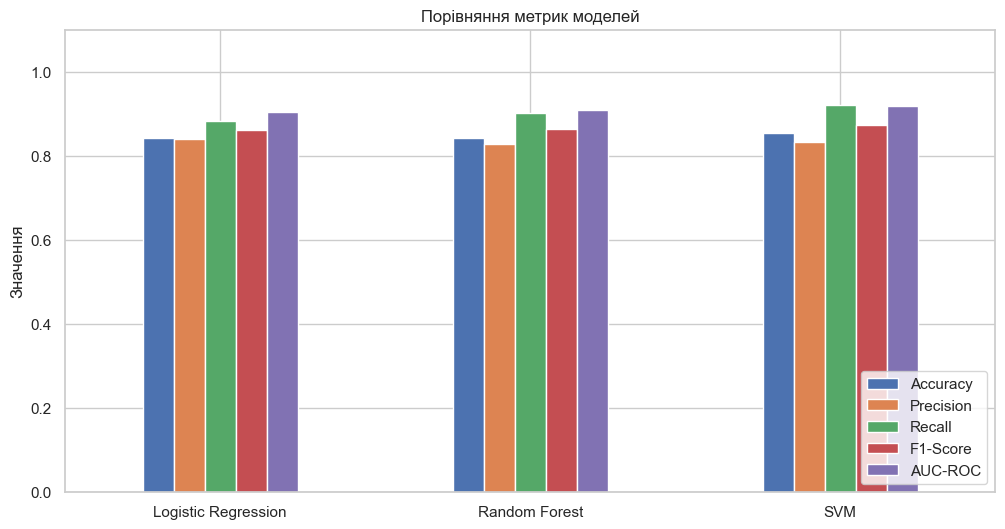

In [10]:
# ==================== СЕКЦІЯ 7: ПОРІВНЯННЯ ТА ВІЗУАЛІЗАЦІЯ РЕЗУЛЬТАТІВ ====================
# Ця клітинка створює таблицю порівняння моделей та графіки

# --- Створення DataFrame з результатами ---
# Перетворюємо словник результатів у таблицю для зручного перегляду
results_df = pd.DataFrame(models_results).T  # .T транспонує таблицю (моделі в рядках)

# Виведення таблиці, відсортованої за Recall (повнотою)
# Recall найбільш важливий для медичних діагнозів (не пропустити хворих)
print("Підсумкова таблиця метрик:")
display(results_df.sort_values(by='Recall', ascending=False))

# --- Графік порівняння всіх метрик ---
# Стовпчастий графік показує значення кожної метрики для кожної моделі
results_df.plot(kind='bar', figsize=(12, 6))
plt.title('Порівняння метрик моделей')
plt.ylabel('Значення')
plt.ylim(0, 1.1)  # Метрики від 0 до 1
plt.xticks(rotation=0)  # Не повертаємо назви моделей
plt.legend(loc='lower right')  # Легенда в нижньому правому куті
plt.show()

In [11]:
# ==================== СЕКЦІЯ 8: ВИБІР НАЙКРАЩОЇ МОДЕЛІ ТА ЗБЕРЕЖЕННЯ ====================
# Ця клітинка вибирає кращу модель та зберігає її для майбутнього використання

# --- Вибір найкращої моделі ---
# Вибираємо модель з найвищим Recall (здатність виявляти хворих пацієнтів)
# idxmax() знаходить індекс (назву) моделі з максимальним значенням
best_model_name = results_df['Recall'].idxmax()
print(f"Найкраща модель за метрикою Recall: {best_model_name}")

# --- Вибір об'єкта моделі на основі назви ---
# Призначаємо кращу навчену модель змінній final_model
if best_model_name == 'Logistic Regression':
    final_model = lr_model
elif best_model_name == 'Random Forest':
    final_model = rf_model
else:
    final_model = svm_model

# --- Збереження артефактів машинного навчання ---
# Ці файли будуть використовуватися додатком (app.py) для роблення прогнозів

# 1. Збереження навченої моделі
# joblib.dump() серіалізує (перетворює на бінарні дані) та зберігає модель у файл
joblib.dump(final_model, 'heart_disease_model.pkl')

# 2. Збереження скейлера
# Скейлер потрібен додатку для нормалізації нових даних перед прогнозом
# Важливо використовувати ТОЙ САМИЙ скейлер, що був навчений на тренувальних даних
joblib.dump(scaler, 'scaler.pkl')

# 3. Збереження переліку ознак
# Список колонок після One-Hot Encoding потрібен для коректного формування входу в модель
# Порядок та назви ознак МАЮТЬ ТОЧНО ВІДПОВІДАТИ тому, що використовувалося при навчанні
feature_names = X.columns.tolist()
joblib.dump(feature_names, 'model_features.pkl')

print("Модель, скейлер та список ознак успішно збережені!")

Найкраща модель за метрикою Recall: SVM
Модель, скейлер та список ознак успішно збережені!
